# Importing required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Loading the dataset

In [2]:
# Loading dataset
df = pd.read_csv('heat_exchanger_dataset.csv')

# Inspecting the data
print(df.head())
print(df.info())

   hot_inlet_temperature_k  cold_inlet_mass_flow_kg_s  \
0                   373.15                   0.500000   
1                   373.15                   0.545455   
2                   373.15                   0.590909   
3                   373.15                   0.636364   
4                   373.15                   0.681818   

   hot_outlet_temperature_k  cold_outlet_temperature_k  hx_1_heat_load_kw  \
0                   378.649                    2011.51            61.3959   
1                   378.394                    2011.51            62.4725   
2                   378.173                    2011.51            63.4044   
3                   377.981                    2011.51            64.2172   
4                   377.811                    2011.51            64.9323   

   hot_outlet_pressure_pa  cold_outlet_pressure_pa  hot_outlet_mass_flow_kg_s  \
0                  500000                   100000                          1   
1                  500000       

# Data preprocessing

In [3]:
# 1. Handle missing values
df = df.dropna()


# Preparing model for clean data

In [4]:
clean_cols = [c for c in df.columns if '_noisy' not in c]
clean_features = [c for c in clean_cols if c != 'hx_1_heat_load_kw']
target_clean = 'hx_1_heat_load_kw'


X_A = df[clean_features]
y_A = df[target_clean]
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(X_A, y_A, test_size=0.2, random_state=42)


#scaling data
scaler = StandardScaler()
X_train_A = scaler.fit_transform(X_train_A)
X_test_A = scaler.transform(X_test_A)

# Preparing model for noisy data

In [5]:
noisy_cols = [c for c in df.columns if '_noisy' in c]
noisy_features = [c for c in noisy_cols if c != 'hx_1_heat_load_kw_noisy']
target_noisy = 'hx_1_heat_load_kw_noisy'

X_B = df[noisy_features]
y_B = df[target_noisy]
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(X_B, y_B, test_size=0.2, random_state=42)

#scaling data
scaler = StandardScaler()
X_train_B = scaler.fit_transform(X_train_A)
X_test_B = scaler.transform(X_test_A)

# Baseline Linear regression model for clean data

In [6]:


lr = LinearRegression()
lr_A = lr.fit(X_train_A, y_train_A)
y_pred_lr_A = lr.predict(X_test_A)

# Baseline Linear regression model for noisy data

In [7]:
lr_B = lr.fit(X_train_B, y_train_B)
y_pred_lr_B = lr.predict(X_test_B)

# Random Forset Regressor for clean data


In [8]:
model_A = RandomForestRegressor(random_state=42).fit(X_train_A, y_train_A)
preds_A = model_A.predict(X_test_A)

# Random Forset Regressor for clean data


In [9]:
model_B = RandomForestRegressor(random_state=42).fit(X_train_B, y_train_B)
preds_B = model_B.predict(X_test_B)

# Hyperparameter Tuning


In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# 1. Define the model
rf = RandomForestRegressor(random_state=42) 

# 2. Hyperparameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}


In [11]:
# Tuning
print("Tuning Model A (Clean)...")
grid_A = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, n_jobs=-1)
grid_A.fit(X_train_A, y_train_A)

print("Tuning Model B (Noisy)...")
grid_B = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, n_jobs=-1)
grid_B.fit(X_train_B, y_train_B)

# Best Models
best_A = grid_A.best_estimator_
best_B = grid_B.best_estimator_

tuned_preds_A = best_A.predict(X_test_A)
tuned_preds_B = best_B.predict(X_test_B)

Tuning Model A (Clean)...
Tuning Model B (Noisy)...


# Results

In [12]:
results = pd.DataFrame({
    'Metric': ['RMSE', 'R2 Score', 'MAE'],
        ' LR Model A (Clean)': [mean_squared_error(y_test_A, y_pred_lr_A), r2_score(y_test_A, y_pred_lr_A),  mean_absolute_error(y_test_A, y_pred_lr_A)],
    'LR Model B (Noisy)': [mean_squared_error(y_test_B, y_pred_lr_B), r2_score(y_test_B, y_pred_lr_B), mean_absolute_error(y_test_B, y_pred_lr_B)],
    'Model A (Clean)': [mean_squared_error(y_test_A, preds_A), r2_score(y_test_A, preds_A),  mean_absolute_error(y_test_A, preds_A)],
    'Model B (Noisy)': [mean_squared_error(y_test_B, preds_B), r2_score(y_test_B, preds_B), mean_absolute_error(y_test_B, preds_B)],
    'Tuned Model A (Clean)': [mean_squared_error(y_test_A, tuned_preds_A), r2_score(y_test_A, tuned_preds_A), mean_absolute_error(y_test_A, tuned_preds_A)],
    'Tuned Model B (Noisy)': [mean_squared_error(y_test_B, tuned_preds_B), r2_score(y_test_B, tuned_preds_B), mean_absolute_error(y_test_B, tuned_preds_B)]})

print(results)

     Metric   LR Model A (Clean)  LR Model B (Noisy)  Model A (Clean)  \
0      RMSE         1.367115e-27          264.089441         0.000737   
1  R2 Score         1.000000e+00            0.586351         0.999998   
2       MAE         3.040057e-14           12.763607         0.005653   

   Model B (Noisy)  Tuned Model A (Clean)  Tuned Model B (Noisy)  
0       329.232651               0.000711             273.159907  
1         0.484315               0.999998               0.572143  
2        14.307020               0.005565              12.985639  


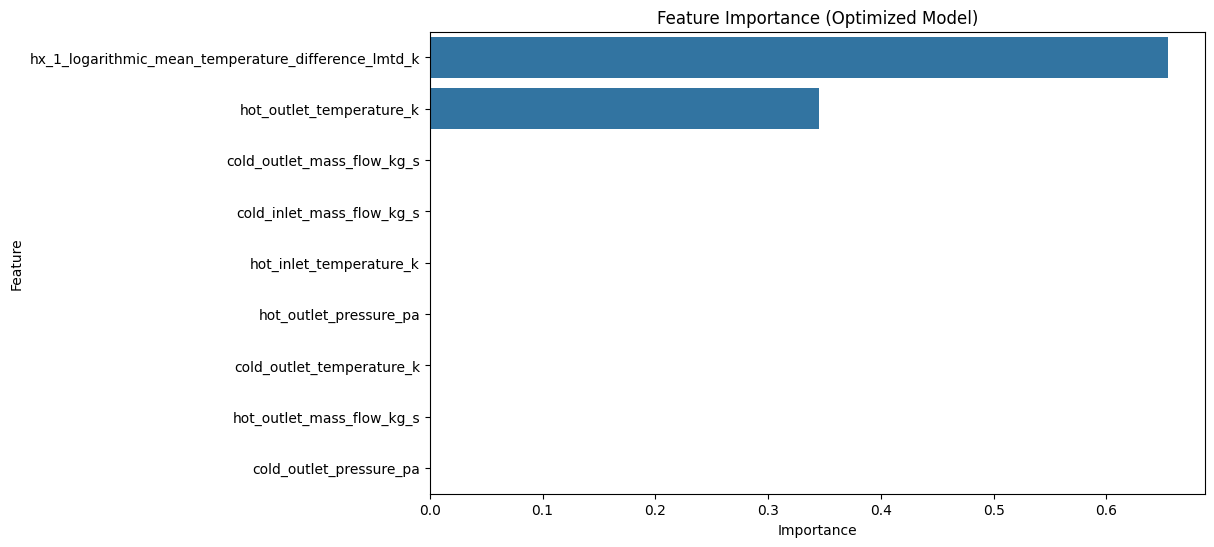

In [13]:
# Plot feature importances
# 1. Get the best estimator from your tuned model (grid_A)
best_rf_model = grid_A.best_estimator_

# 2. Extract importances
importances = best_rf_model.feature_importances_
feature_names = X_A.columns

# 3. Create a DataFrame for easier sorting and plotting
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# 4. Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df)
plt.title('Feature Importance (Optimized Model)')
plt.show()

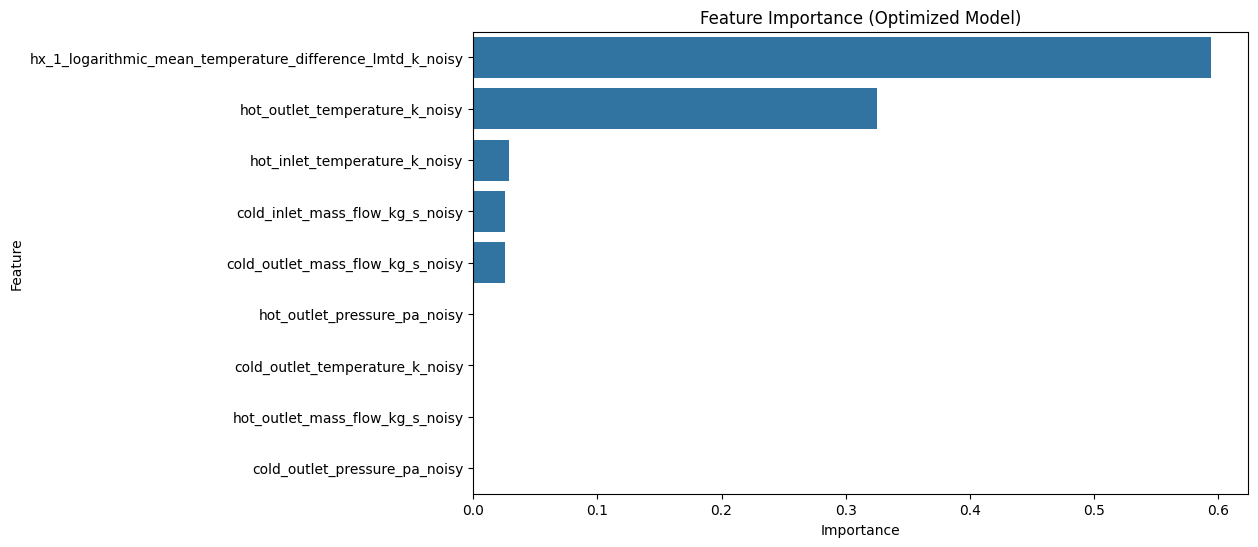

In [14]:
# 1. Get the best estimator from your tuned model (grid_A)
best_rf_model = grid_B.best_estimator_

# 2. Extract importances
importances = best_rf_model.feature_importances_
feature_names = X_B.columns

# 3. Create a DataFrame for easier sorting and plotting
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# 4. Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df)
plt.title('Feature Importance (Optimized Model)')
plt.show()

# Visualization

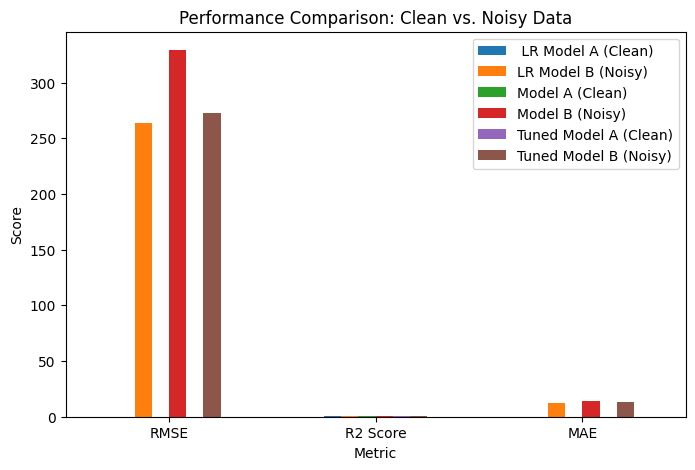

In [15]:
results.set_index('Metric').plot(kind='bar', figsize=(8, 5))
plt.title('Performance Comparison: Clean vs. Noisy Data')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

In [20]:
import joblib

joblib.dump(model_A, 'heat_exchanger_model_A.pkl')

joblib.dump(model_B, 'heat_exchanger_model_B.pkl')

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']